# Poisson Equation — Steady-State Source

$$\nabla^2 p = \frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} = f(x, y)$$

**Where:**
- $p(x, y)$ = the field we are solving for (pressure, temperature, electric potential)
- $\frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2}$ = the **Laplacian** — measures how much $p$ at a point differs from its surroundings
- $f(x, y)$ = the **source term** — something injecting or removing quantity at every point in space

The **Poisson equation** describes how a source term $f(x,y)$ drives a steady-state field across a 2D domain. There is no time dependence — we are looking for the field that *permanently* balances the source.

**Physical meaning:** Imagine heat being generated inside a metal plate at every point according to $f(x,y)$, with the edges held at zero. The Poisson equation tells you what the final temperature distribution looks like when generation and conduction perfectly balance. No more change in time — just a frozen spatial landscape shaped by the source.

**The leap from diffusion to Poisson:** In 2D diffusion, we watched a field evolve in time until it settled. The Poisson equation skips straight to that final answer. It is the steady-state limit — $\frac{\partial p}{\partial t} = 0$ — which is why there are **no initial condition points** at all. The PINN only sees boundary constraints and interior physics.

---

## This Problem Setup

**Domain:** $x \in [0, 1]$, $y \in [0, 1]$ (purely spatial — no time axis)

**Source Term:**

$$f(x, y) = -2\pi^2 \sin(\pi x)\sin(\pi y)$$

**Exact Solution:**

$$p(x, y) = \sin(\pi x)\sin(\pi y)$$

You can verify this yourself: take two spatial derivatives and you recover exactly $f(x,y)$. Like the 2D Burgers problem, we have a known ground truth — the PINN is being trained to rediscover it from boundary data and PDE residuals alone.

**Boundary Conditions (Dirichlet):**

$$p = 0 \quad \text{on all four walls}$$

All edges are held at zero — 1000 boundary points total, 250 randomly placed per edge.

**Physics Points:** $50 \times 50 = 2500$ interior collocation points on a uniform spatial grid, where the PINN enforces $\nabla^2 p = f(x,y)$. No time grid needed — this is a 2D problem only.

In [5]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import optax
import copy

# ============ DOMAIN PARAMETERS ============
L = 1.0          # domain size [0, L] x [0, L]

""""
We will use exact solution: p(x, y) = sin(pi*x) * sin(pi*y) which satisfies the Poisson equation 
with f(x, y) = -2*pi^2*sin(pi*x)*sin(pi*y) and zero Dirichlet boundary conditions.
"""

key = random.PRNGKey(0)

# 1. Poisson has no time dependence, so there is no IC points. We will only have boundary points and physics points in the interior.

# 2. Boundary Condition points (250 each side, total 1000 points)

k3, k4, k5, k6, k7, k8, k9, k10 = random.split(key, 8)
N_per_edge = 250

x_left = jnp.zeros((N_per_edge, 1))
y_left = random.uniform(k3, (N_per_edge, 1), minval=0.0, maxval=L)

x_right = jnp.ones((N_per_edge, 1)) * L
y_right = random.uniform(k5, (N_per_edge, 1), minval=0.0, maxval=L)

x_bottom = random.uniform(k7, (N_per_edge, 1), minval=0.0, maxval=L)
y_bottom = jnp.zeros((N_per_edge, 1))

x_top = random.uniform(k9, (N_per_edge, 1), minval=0.0, maxval=L)
y_top = jnp.ones((N_per_edge, 1)) * L

# Combine all boundary points
x_bc = jnp.concatenate([x_left, x_right, x_bottom, x_top])
y_bc = jnp.concatenate([y_left, y_right, y_bottom, y_top])
p_bc = jnp.zeros((N_per_edge * 4, 1))  # u=0 at all boundaries

# 3. Physics points (50*50 = 2500 points in the interior of the domain)
x_vals = jnp.linspace(0, L, 50)
y_vals = jnp.linspace(0, L, 50)
x_grid, y_grid = jnp.meshgrid(x_vals, y_vals)  # Shape (50, 50)
x_physics = x_grid.reshape(-1, 1)  # Shape (2500, 1)
y_physics = y_grid.reshape(-1, 1)  # Shape (2500, 1)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g., [2, 64, 64, 64, 1] for 2 inputs, 3 hidden layers of 64 neurons, and 1 output
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization
        
    Returns:
        params: List of dictionaries, each containing 'w' and 'b'
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))
    
    params = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        params.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    for layer in params[:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params[-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, x_point, y_point,):

    def p(x_val, y_val):
        xy_in = jnp.array([[x_val, y_val]])  # Shape (1, 2)
        return network(params, xy_in)[0, 0]
    

    d2p_dx2 = grad(grad(p, argnums = 0), argnums=0)(x_point, y_point)
    d2p_dy2 = grad(grad(p, argnums = 1), argnums=1)(x_point, y_point)

    return d2p_dx2 + d2p_dy2 + 2 * jnp.pi**2 * jnp.sin(jnp.pi * x_point) * jnp.sin(jnp.pi * y_point)
    

# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 900 times, once for each (x, y) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 1]  # 2 inputs (x, y), 1 output (p)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
schedule = optax.cosine_decay_schedule(
    init_value=1e-3,
    decay_steps=40000,
    alpha=1e-5 / 1e-3   # ratio of final_lr / init_lr
)
optimizer = optax.adam(learning_rate=schedule)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state, 
                x_bc, y_bc, p_bc, x_physics, y_physics):

    def loss_fn(params):
        
        # 2. Boundary Condition Loss
        xy_bc = jnp.concatenate([x_bc, y_bc], axis=1)
        p_pred_bc = network(params, xy_bc)
        bc_loss = jnp.mean((p_pred_bc - p_bc)**2)
        
        # 3. Physics Loss
        physics_residuals = physics_residual_batch(params,  
                                                x_physics.ravel(), 
                                                y_physics.ravel(), 
                                                )

        physics_loss = jnp.mean(physics_residuals**2) 

        # return total loss plus a tuple of the individual components as auxiliary data
        return 10 * bc_loss + physics_loss, (bc_loss, physics_loss)
    
        # Compute loss and gradients; use has_aux=True so we can extract the individual losses
    (loss_val, indivicual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, indivicual_loss


# Training parameters
num_iterations = 40000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
x_phys_flat = x_physics.ravel()
y_phys_flat = y_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_physics = []
for i in range(num_iterations):
    params, opt_state, loss, individual_losses = update_step(
        params, opt_state,
        x_bc, y_bc, p_bc,
        x_phys_flat, y_phys_flat
    )
    
    losses.append(loss)
    losses_bc.append(individual_losses[0])
    losses_physics.append(individual_losses[1])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    # Print progress every 1000 iterations
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f" BC Loss: {individual_losses[0]:.6f}, Physics Loss: {individual_losses[1]:.6f}")


Iteration 1000/40000, Loss: 0.058546
 BC Loss: 0.004768, Physics Loss: 0.010867
Iteration 2000/40000, Loss: 0.007298
 BC Loss: 0.000428, Physics Loss: 0.003021
Iteration 3000/40000, Loss: 0.010117
 BC Loss: 0.000240, Physics Loss: 0.007716
Iteration 4000/40000, Loss: 0.002302
 BC Loss: 0.000061, Physics Loss: 0.001691
Iteration 5000/40000, Loss: 0.002278
 BC Loss: 0.000047, Physics Loss: 0.001805
Iteration 6000/40000, Loss: 0.002495
 BC Loss: 0.000018, Physics Loss: 0.002313
Iteration 7000/40000, Loss: 0.001165
 BC Loss: 0.000026, Physics Loss: 0.000906
Iteration 8000/40000, Loss: 0.000415
 BC Loss: 0.000009, Physics Loss: 0.000325
Iteration 9000/40000, Loss: 0.000559
 BC Loss: 0.000006, Physics Loss: 0.000495
Iteration 10000/40000, Loss: 0.000314
 BC Loss: 0.000007, Physics Loss: 0.000243
Iteration 11000/40000, Loss: 0.001303
 BC Loss: 0.000011, Physics Loss: 0.001198
Iteration 12000/40000, Loss: 0.000411
 BC Loss: 0.000005, Physics Loss: 0.000364
Iteration 13000/40000, Loss: 0.000219

## Loss curve

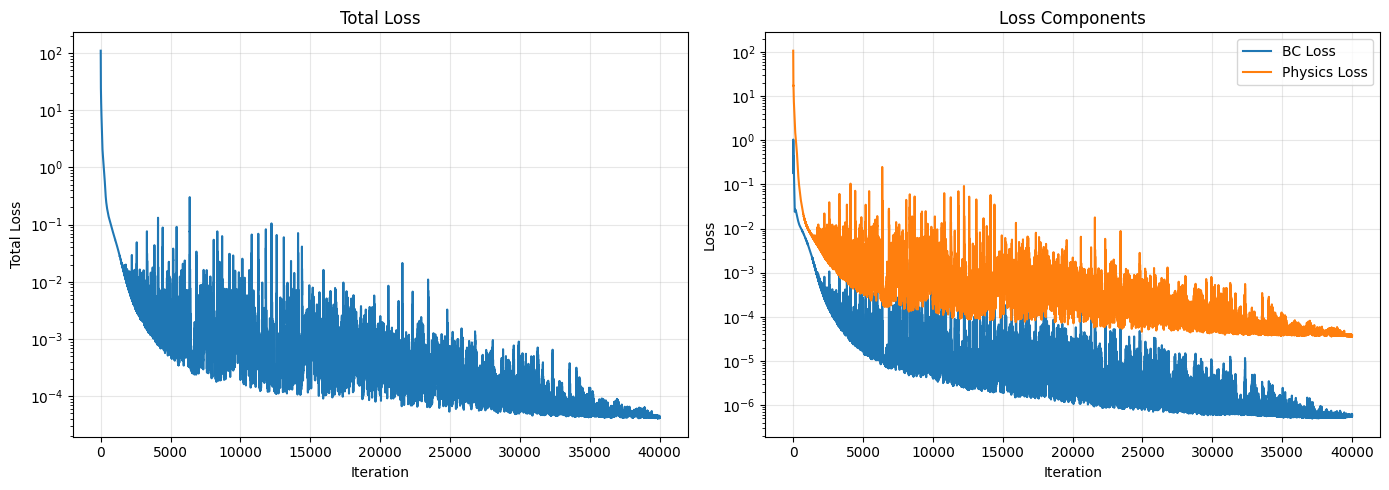

In [6]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

iterations = np.arange(1, len(losses) + 1)

# Left: total loss
ax1.semilogy(iterations, losses)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Total Loss')
ax1.set_title('Total Loss')
ax1.grid(True, alpha=0.3)

# Right: individual components
ax2.semilogy(iterations, losses_bc, label='BC Loss')
ax2.semilogy(iterations, losses_physics, label='Physics Loss')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Loss')
ax2.set_title('Loss Components')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('poisson_loss_curves.png', dpi=150)
plt.show()

## Evaluation grid

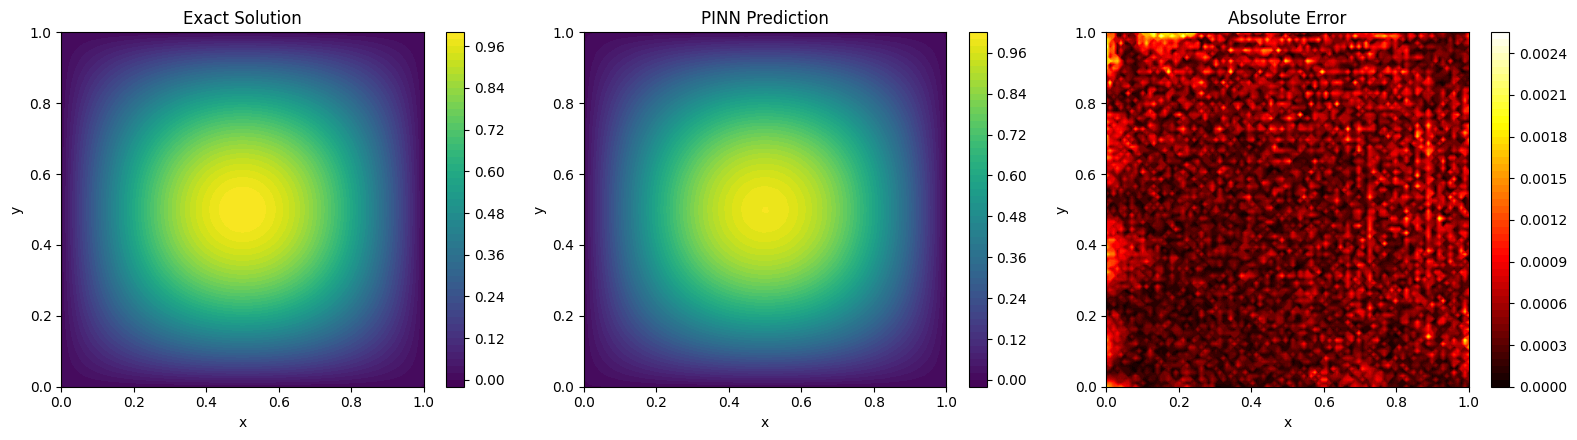

Relative L2 Error: 0.001012


In [7]:
# Create evaluation grid
N_eval = 100
x_eval = jnp.linspace(0, L, N_eval)
y_eval = jnp.linspace(0, L, N_eval)
X_eval, Y_eval = jnp.meshgrid(x_eval, y_eval)

# Flatten for network input
xy_eval = jnp.stack([X_eval.ravel(), Y_eval.ravel()], axis=1)  # Shape (10000, 2)

# Predict
p_pred = network(params, xy_eval).reshape(N_eval, N_eval)

# Exact solution
p_exact = jnp.sin(jnp.pi * X_eval) * jnp.sin(jnp.pi * Y_eval)

# Error
error = jnp.abs(p_pred - p_exact)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im0 = axes[0].contourf(X_eval, Y_eval, p_exact, levels=50, cmap='viridis')
axes[0].set_title('Exact Solution')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X_eval, Y_eval, p_pred, levels=50, cmap='viridis')
axes[1].set_title('PINN Prediction')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X_eval, Y_eval, error, levels=50, cmap='hot')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('poisson_solution.png', dpi=150)
plt.show()

# Compute relative L2 error
rel_l2 = jnp.sqrt(jnp.sum((p_pred - p_exact)**2)) / jnp.sqrt(jnp.sum(p_exact**2))
print(f"Relative L2 Error: {rel_l2:.6f}")

## Training animations

In [8]:
"""
Poisson PINN — 3D Training Animations
Run this AFTER your training script (needs: snapshots, snapshot_iterations, params, network, L)
"""

import jax.numpy as jnp
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import numpy as np

# ============================================
# EVALUATION GRID
# ============================================
N_eval = 80
x_eval = jnp.linspace(0, L, N_eval)
y_eval = jnp.linspace(0, L, N_eval)
X_eval, Y_eval = jnp.meshgrid(x_eval, y_eval)
xy_eval = jnp.stack([X_eval.ravel(), Y_eval.ravel()], axis=1)

# Exact solution on grid
P_exact = jnp.sin(jnp.pi * X_eval) * jnp.sin(jnp.pi * Y_eval)

# Convert to numpy for matplotlib
X_np = np.array(X_eval)
Y_np = np.array(Y_eval)
P_exact_np = np.array(P_exact)


# ============================================
# ANIMATION 1: 3D Surface — PINN Learning
# Shows the predicted surface evolving over training
# ============================================

print("Generating predictions for all snapshots...")
predictions = []
for i, snap_params in enumerate(snapshots):
    p_pred = network(snap_params, xy_eval).reshape(N_eval, N_eval)
    predictions.append(np.array(p_pred))
    if (i + 1) % 50 == 0:
        print(f"  Computed {i+1}/{len(snapshots)} snapshots")

print("Building Animation 1: 3D surface evolution...")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Select frames (every 4th snapshot to keep GIF reasonable)
frame_skip = 4
frame_indices = list(range(0, len(snapshots), frame_skip))
# Always include last frame
if frame_indices[-1] != len(snapshots) - 1:
    frame_indices.append(len(snapshots) - 1)

def update_surface(frame_idx):
    ax.clear()
    idx = frame_indices[frame_idx]
    
    # Plot PINN prediction as solid surface
    ax.plot_surface(X_np, Y_np, predictions[idx],
                    cmap='viridis', alpha=0.9,
                    rstride=2, cstride=2,
                    edgecolor='none')
    
    # Plot exact solution as wireframe for reference
    ax.plot_wireframe(X_np, Y_np, P_exact_np,
                      color='red', alpha=0.15,
                      rstride=6, cstride=6,
                      linewidth=0.5)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(-0.3, 1.1)
    ax.set_xlabel('x', fontsize=12, labelpad=8)
    ax.set_ylabel('y', fontsize=12, labelpad=8)
    ax.set_zlabel('p(x,y)', fontsize=12, labelpad=8)
    ax.set_title(f'Poisson PINN — Iteration {snapshot_iterations[idx]:,}',
                 fontsize=14, fontweight='bold', pad=15)
    ax.view_init(elev=25, azim=-60 + frame_idx * 0.3)  # Slow rotation!
    
    return []

anim1 = animation.FuncAnimation(fig, update_surface,
                                 frames=len(frame_indices),
                                 interval=80, blit=False)
anim1.save('poisson_3d_learning.gif', writer='pillow', fps=12, dpi=100)
plt.close()
print("Saved: poisson_3d_learning.gif")


# ============================================
# ANIMATION 2: Error Surface Shrinking
# 3D view of |prediction - exact| collapsing to zero
# ============================================

print("Building Animation 2: Error surface collapse...")

fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')

# Precompute max error for consistent color scaling
max_error_global = max(np.max(np.abs(pred - P_exact_np)) for pred in predictions)

def update_error(frame_idx):
    ax2.clear()
    idx = frame_indices[frame_idx]
    
    error = np.abs(predictions[idx] - P_exact_np)
    
    # Color based on error magnitude
    ax2.plot_surface(X_np, Y_np, error,
                     cmap='hot', alpha=0.92,
                     rstride=2, cstride=2,
                     edgecolor='none',
                     vmin=0, vmax=max_error_global * 0.5)  # cap color range so late frames aren't invisible
    
    # Reference plane at zero
    ax2.plot_surface(X_np, Y_np, np.zeros_like(X_np),
                     color='green', alpha=0.08)
    
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_zlim(0, max_error_global * 1.05)
    ax2.set_xlabel('x', fontsize=12, labelpad=8)
    ax2.set_ylabel('y', fontsize=12, labelpad=8)
    ax2.set_zlabel('|Error|', fontsize=12, labelpad=8)
    
    max_err_now = np.max(error)
    ax2.set_title(f'Error Collapse — Iter {snapshot_iterations[idx]:,}  |  Max Error: {max_err_now:.4f}',
                  fontsize=13, fontweight='bold', pad=15)
    ax2.view_init(elev=30, azim=-50 + frame_idx * 0.3)
    
    return []

anim2 = animation.FuncAnimation(fig2, update_error,
                                 frames=len(frame_indices),
                                 interval=80, blit=False)
anim2.save('poisson_error_collapse.gif', writer='pillow', fps=12, dpi=100)
plt.close()
print("Saved: poisson_error_collapse.gif")


# ============================================
# ANIMATION 3: Side-by-side 2D heatmaps
# Exact | Prediction | Error evolving together
# ============================================

print("Building Animation 3: Side-by-side heatmap evolution...")

fig3, axes3 = plt.subplots(1, 3, figsize=(16, 5))

def update_heatmaps(frame_idx):
    idx = frame_indices[frame_idx]
    
    for ax in axes3:
        ax.clear()
    
    error = np.abs(predictions[idx] - P_exact_np)
    
    im0 = axes3[0].contourf(X_np, Y_np, P_exact_np, levels=40, cmap='viridis', vmin=0, vmax=1)
    axes3[0].set_title('Exact Solution', fontsize=12)
    axes3[0].set_xlabel('x')
    axes3[0].set_ylabel('y')
    axes3[0].set_aspect('equal')
    
    im1 = axes3[1].contourf(X_np, Y_np, predictions[idx], levels=40, cmap='viridis', vmin=0, vmax=1)
    axes3[1].set_title(f'PINN — Iter {snapshot_iterations[idx]:,}', fontsize=12, fontweight='bold')
    axes3[1].set_xlabel('x')
    axes3[1].set_ylabel('y')
    axes3[1].set_aspect('equal')
    
    im2 = axes3[2].contourf(X_np, Y_np, error, levels=40, cmap='hot', vmin=0, vmax=0.1)
    axes3[2].set_title(f'|Error|  (max: {np.max(error):.4f})', fontsize=12)
    axes3[2].set_xlabel('x')
    axes3[2].set_ylabel('y')
    axes3[2].set_aspect('equal')
    
    fig3.suptitle('Poisson Equation PINN Training', fontsize=15, fontweight='bold', y=1.02)
    
    return []

anim3 = animation.FuncAnimation(fig3, update_heatmaps,
                                 frames=len(frame_indices),
                                 interval=80, blit=False)
anim3.save('poisson_heatmap_evolution.gif', writer='pillow', fps=12, dpi=100)
plt.close()
print("Saved: poisson_heatmap_evolution.gif")


# ============================================
# STATIC POSTER: Final result comparison
# Nice single image for X posts
# ============================================

print("Building static poster image...")

fig4 = plt.figure(figsize=(18, 5))

# 3D Exact
ax_a = fig4.add_subplot(131, projection='3d')
ax_a.plot_surface(X_np, Y_np, P_exact_np, cmap='viridis', edgecolor='none', rstride=2, cstride=2)
ax_a.set_title('Exact: sin(πx)sin(πy)', fontsize=13, fontweight='bold', pad=12)
ax_a.set_xlabel('x'); ax_a.set_ylabel('y'); ax_a.set_zlabel('p')
ax_a.set_zlim(0, 1.1)
ax_a.view_init(elev=25, azim=-60)

# 3D PINN
ax_b = fig4.add_subplot(132, projection='3d')
ax_b.plot_surface(X_np, Y_np, predictions[-1], cmap='viridis', edgecolor='none', rstride=2, cstride=2)
ax_b.set_title(f'PINN Prediction (L² err: {0.001012:.4f})', fontsize=13, fontweight='bold', pad=12)
ax_b.set_xlabel('x'); ax_b.set_ylabel('y'); ax_b.set_zlabel('p')
ax_b.set_zlim(0, 1.1)
ax_b.view_init(elev=25, azim=-60)

# 3D Error
final_error = np.abs(predictions[-1] - P_exact_np)
ax_c = fig4.add_subplot(133, projection='3d')
ax_c.plot_surface(X_np, Y_np, final_error, cmap='hot', edgecolor='none', rstride=2, cstride=2)
ax_c.set_title(f'Absolute Error (max: {np.max(final_error):.4f})', fontsize=13, fontweight='bold', pad=12)
ax_c.set_xlabel('x'); ax_c.set_ylabel('y'); ax_c.set_zlabel('|err|')
ax_c.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig('poisson_poster.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print("Saved: poisson_poster.png")

print("\nAll done! You have:")
print("  1. poisson_3d_learning.gif    — 3D surface emerging with slow camera rotation")
print("  2. poisson_error_collapse.gif — Error mountain collapsing to flat")
print("  3. poisson_heatmap_evolution.gif — Side-by-side 2D heatmaps")
print("  4. poisson_poster.png         — Static 3D comparison (great for X)")

Generating predictions for all snapshots...
  Computed 50/266 snapshots
  Computed 100/266 snapshots
  Computed 150/266 snapshots
  Computed 200/266 snapshots
  Computed 250/266 snapshots
Building Animation 1: 3D surface evolution...
Saved: poisson_3d_learning.gif
Building Animation 2: Error surface collapse...
Saved: poisson_error_collapse.gif
Building Animation 3: Side-by-side heatmap evolution...
Saved: poisson_heatmap_evolution.gif
Building static poster image...
Saved: poisson_poster.png

All done! You have:
  1. poisson_3d_learning.gif    — 3D surface emerging with slow camera rotation
  2. poisson_error_collapse.gif — Error mountain collapsing to flat
  3. poisson_heatmap_evolution.gif — Side-by-side 2D heatmaps
  4. poisson_poster.png         — Static 3D comparison (great for X)
